In [7]:
from sklearn.datasets import make_classification
import numpy as np

In [8]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
lor = LogisticRegression()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.2,random_state = 23)

In [13]:
lor.fit(X_train,y_train)

LogisticRegression()

In [21]:
lor.coef_,lor.intercept_

(array([[ 1.71575029, -0.0244466 ]]), array([3.50759268]))

In [22]:
line_m_st = -(lor.coef_.ravel()[0]/lor.coef_.ravel()[1])
line_b_st = -(lor.intercept_/lor.coef_.ravel()[1])

In [23]:
x_i = np.linspace(-3, 3, 100)
y_line_st = line_m_st*x_i + line_b_st


In [24]:
import matplotlib.pyplot as plt

(-3.0, 2.0)

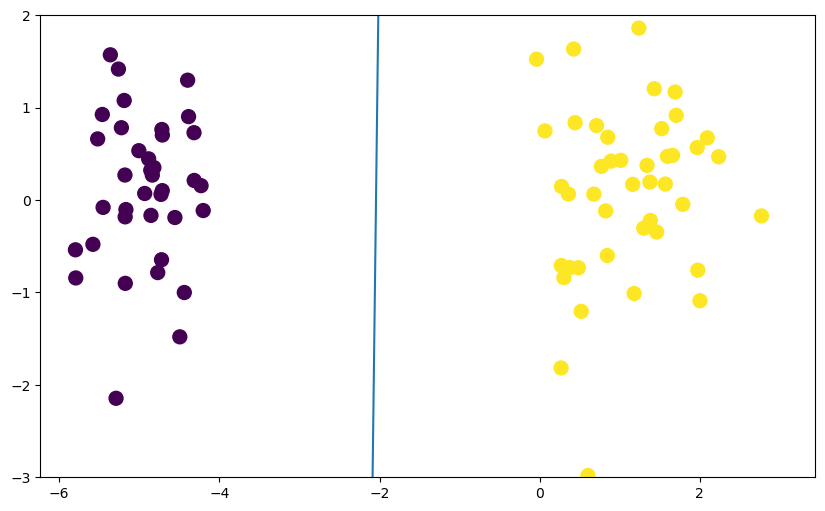

In [25]:
plt.figure(figsize=(10,6))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,s=100)
plt.plot(x_i,y_line_st)
plt.ylim(-3,2)

In [63]:
def CustomLogisticRegressor(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.5
    
    for i in range(5000):
        y_hat = sigmoid(np.dot(X,weights))
        weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
        
    return weights[1:],weights[0]
        

In [61]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

In [64]:
intercept_,coef_ = CustomLogisticRegressor(X_train,y_train)

In [65]:
intercept_,coef_

(array([3.47890583, 0.09979106]), 5.267654504492845)

In [66]:
lor.predict(X_test)

array([0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1])

In [67]:
from sklearn.metrics import accuracy_score,confusion_matrix

In [68]:
accuracy_score(y_test,lor.predict(X_test))

1.0